In [9]:
from google.colab import files
import os

#Tải file kaggle.json
path = "/content/kaggle.json"
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
#tải bộ dữ liệu 5 loại hoa từ Kaggle
!kaggle datasets download -d alxmamaev/flowers-recognition
#Giải nén
import zipfile
with zipfile.ZipFile("flowers-recognition.zip", "r") as zip_ref:
    zip_ref.extractall("flowers_data")

Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
flowers-recognition.zip: Skipping, found more recently modified local copy (use --force to force download)


In [10]:
import os
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img

train_dir = 'flowers_data/flowers/'
img_width, img_height = 128, 128
batch_size = 32
num_classes = 5  #daisy, dandelion, rose, sunflower, tulip

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


In [11]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,941,381 (49.37 MB)

 Trainable params: 12,941,381 (49.37 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
epochs = 30
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs
)
model.save('flowers_recognition_model.h5')

Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.4139 - loss: 1.3179 - val_accuracy: 0.5047 - val_loss: 1.2107
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.5725 - loss: 1.0819 - val_accuracy: 0.6000 - val_loss: 0.9902
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.6049 - loss: 1.0062 - val_accuracy: 0.5721 - val_loss: 1.0231
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.6242 - loss: 0.9615 - val_accuracy: 0.6291 - val_loss: 0.9211
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.6451 - loss: 0.9259 - val_accuracy: 0.6233 - val_loss: 0.9773
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.6537 - loss: 0.8894 - val_accuracy: 0.6453 - val_loss: 0.9554
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.6633 - loss: 0.8742 - val_accuracy: 0.6698 - val_loss: 0.8272
Epoch 8/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.6804 - loss: 0.8375 - val_accu

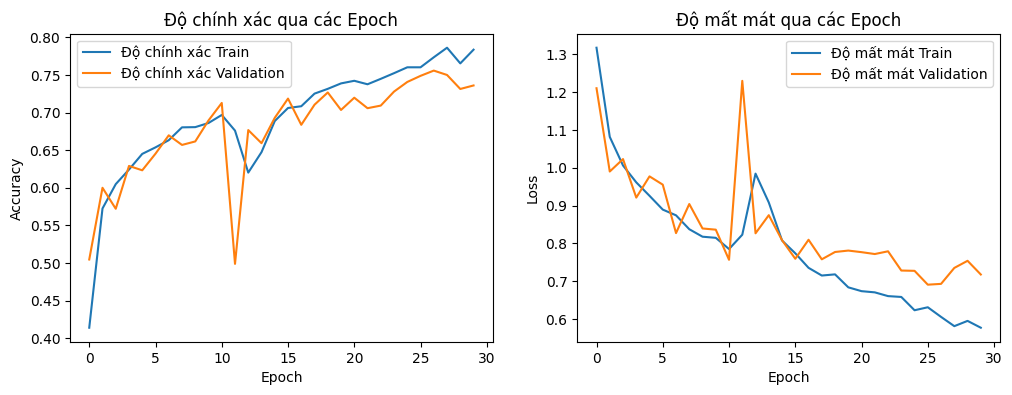

In [20]:
plt.figure(figsize=(12, 4))
#đánh giá
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Độ chính xác Train')
plt.plot(history.history['val_accuracy'], label='Độ chính xác Validation')
plt.title('Độ chính xác qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Độ mất mát Train')
plt.plot(history.history['val_loss'], label='Độ mất mát Validation')
plt.title('Độ mất mát qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
import tensorflow as tf
#Đánh giá kết quả mô hình
best_model = tf.keras.models.load_model('/content/flowers_recognition_model.h5')
train_loss, train_accuracy = best_model.evaluate(train_generator)
val_loss, val_accuracy = best_model.evaluate(validation_generator)
print(f"Độ chính xác thực tế trên tập Train: {train_accuracy*100:.2f}%")
print(f"Độ chính xác thực tế trên tập Validation: {val_accuracy*100:.2f}%")

109/109 ━━━━━━━━━━━━━━━━━━━━ 58s 523ms/step - accuracy: 0.7776 - loss: 0.5830
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 444ms/step - accuracy: 0.7244 - loss: 0.7008
Độ chính xác thực tế trên tập Train: 77.76%
Độ chính xác thực tế trên tập Validation: 72.44%


In [23]:
def predict_flower(test_img_path):
    img = load_img(test_img_path, target_size=(128, 128))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    img_array = np.array(img) / 255.0
    img_array = img_array.reshape((1, 128, 128, 3))
    predictions = best_model.predict(img_array)
    prediction_idx = np.argmax(predictions)
    class_labels = {v: k for k, v in train_generator.class_indices.items()}
    flower_name = class_labels[prediction_idx]
    confidence = predictions[0][prediction_idx] * 100
    print(f"Kết quả dự đoán: {flower_name} (Độ tin cậy: {confidence:.2f}%)")
    return flower_name

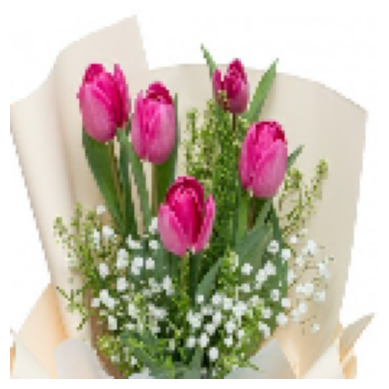

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Kết quả dự đoán: tulip (Độ tin cậy: 71.34%)


In [25]:
predicted_label = predict_flower('/content/tulip.jpg')

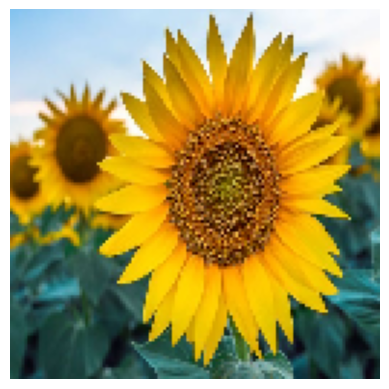

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Kết quả dự đoán: sunflower (Độ tin cậy: 99.03%)


In [26]:
predicted_label = predict_flower('/content/huongduong.jpg')

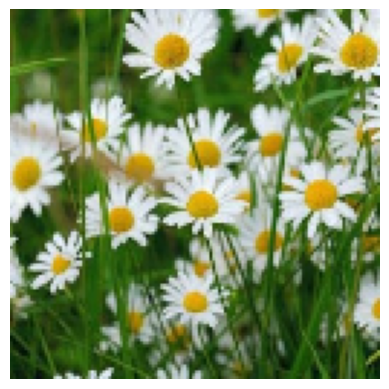

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Kết quả dự đoán: daisy (Độ tin cậy: 100.00%)


In [27]:
predicted_label = predict_flower('/content/daisy.jpg')

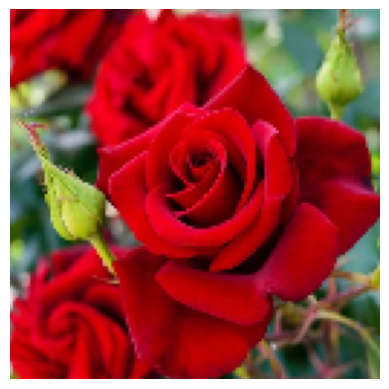

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Kết quả dự đoán: rose (Độ tin cậy: 95.81%)


In [28]:
predicted_label = predict_flower('/content/hong.jpg')

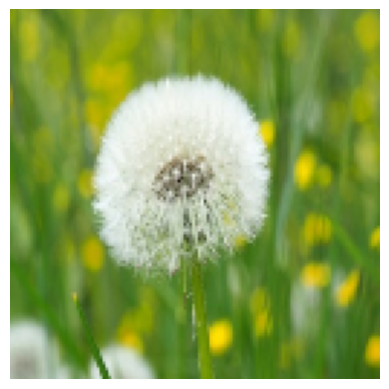

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Kết quả dự đoán: dandelion (Độ tin cậy: 80.65%)


In [29]:
predicted_label = predict_flower('/content/boconganh.jpg')